Primer paso: cargamos las librerías necesarias

In [19]:
import sys
from pathlib import Path
import yaml
import cv2
import numpy as np
from skimage import morphology
from shapely.geometry import Point
from shapely.geometry.polygon import Polygon
import matplotlib.pyplot as plt

Segundo paso: cargar el archivo del mapa y procesarlo

YAML cargado: \\wsl.localhost\Ubuntu-20.04\home\ubuntu20\Ubuntu20noetic_ws\src\robots_moviles\navegacion_geometrica\mapas\exploration\mapa_escenario1.yaml
Mapa cargado: \\wsl.localhost\Ubuntu-20.04\home\ubuntu20\Ubuntu20noetic_ws\src\robots_moviles\navegacion_geometrica\mapas\exploration\mapa_escenario1.pgm


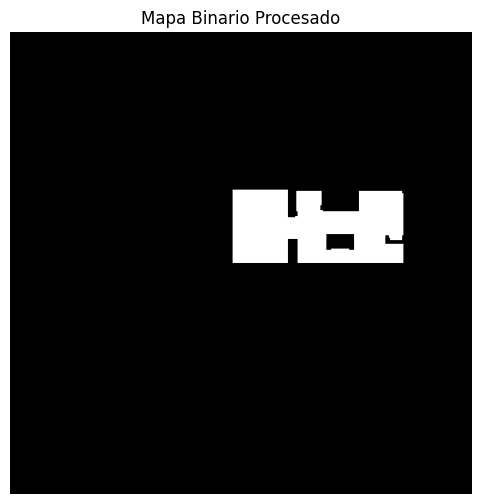

In [ ]:
archivo_yaml = 'mapa_escenario2.yaml'  # Sustituir por el nombre del archivo correspondiente

# Resolucion robusta de rutas para ejecutar desde Jupyter/Colab/local
candidatos_yaml = [
    Path(archivo_yaml),
    Path.cwd() / archivo_yaml,
    Path.cwd() / 'navegacion_geometrica' / 'mapas' / 'exploration' / archivo_yaml,
    Path.cwd() / 'navegacion_geometrica' / 'mapas' / 'sensores' / archivo_yaml,
]

ruta_yaml = next((p.resolve() for p in candidatos_yaml if p.exists()), None)
if ruta_yaml is None:
    raise FileNotFoundError(f'No se encontro el YAML. Revisa archivo_yaml: {archivo_yaml}')

with open(ruta_yaml, 'r') as file:
    metadatos = yaml.safe_load(file)

ruta_mapa = (ruta_yaml.parent / metadatos["image"]).resolve()
if not ruta_mapa.exists():
    ruta_mapa_alt = (Path.cwd() / metadatos["image"]).resolve()
    if ruta_mapa_alt.exists():
        ruta_mapa = ruta_mapa_alt
    else:
        raise FileNotFoundError(f'No se encontro la imagen del mapa: {metadatos["image"]}')

mapa = cv2.imread(str(ruta_mapa), -1)
res = metadatos["resolution"]
oriX, oriY = metadatos["origin"][:2]

# Transformamos la imagen del mapa a una imagen binaria para poder procesarla
# Nota: algunos mapas libres usan 254 y otros 255
mapa_binario = np.where((mapa >= 250), 255, 0).astype(np.uint8)

# Aplicamos filtros para eliminar ruido
mapa_binario = cv2.morphologyEx(mapa_binario, cv2.MORPH_OPEN, np.ones((7, 7), np.uint8))
mapa_binario = cv2.erode(mapa_binario, np.ones((3, 3), np.uint8), iterations=1)

pix_libres = int(np.sum(mapa_binario == 255))
pix_obs = int(np.sum(mapa_binario == 0))
print(f'YAML cargado: {ruta_yaml}')
print(f'Mapa cargado: {ruta_mapa}')
print(f'Pixeles libres: {pix_libres} | obstaculos: {pix_obs}')

# Visualizamos el resultado
plt.figure(figsize=(6, 6))
plt.imshow(mapa_binario, cmap='gray')
plt.title("Mapa Binario Procesado")
plt.axis("off")
plt.show()

Tercer paso: aplicación de segmentación mediante Watershed

Umbral Watershed usado: 0.3
Regiones detectadas (>1): 1 -> [2]


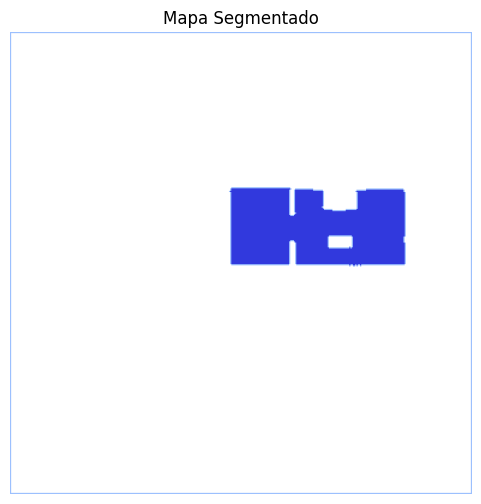

In [21]:
# Aplicamos watershed (https://docs.opencv.org/4.x/d3/db4/tutorial_py_watershed.html)

# 1) Preprocesado mediante dilatacion y transformacion de distancia
kernel = np.ones((3, 3), np.uint8)
fondo = cv2.dilate(mapa_binario, kernel, iterations=3)
dist_transform = cv2.distanceTransform(mapa_binario, cv2.DIST_L2, 5)

# 2) Busqueda adaptativa de umbral (MUY sesgada a valores altos):
# Si sobresegmenta, forzamos segmentacion gruesa.
factores_umbral = [0.4]
mejor = None
resultados = []

for factor_umbral in factores_umbral:
    _, frente = cv2.threshold(dist_transform, factor_umbral * dist_transform.max(), 255, 0)
    frente = np.uint8(frente)

    desconocido = cv2.subtract(fondo, frente)
    _, etiquetas_tmp = cv2.connectedComponents(frente)
    etiquetas_tmp = etiquetas_tmp + 1
    etiquetas_tmp[desconocido == 255] = 0
    etiquetas_tmp = cv2.watershed(cv2.cvtColor(mapa, cv2.COLOR_GRAY2BGR), etiquetas_tmp)

    regiones = [int(x) for x in np.unique(etiquetas_tmp) if x > 1]
    areas = [int(np.sum(etiquetas_tmp == r)) for r in regiones]

    # puntuacion: preferimos 4-10 regiones y regiones mas grandes
    n_reg = len(regiones)
    area_media = float(np.mean(areas)) if areas else 0.0
    penalizacion_n = abs(n_reg - 6)
    score = area_media - (penalizacion_n * 700.0)

    resultados.append((factor_umbral, n_reg, area_media, score))

    # descartamos extremos
    if n_reg < 2 or n_reg > 25:
        continue

    if (mejor is None) or (score > mejor["score"]):
        mejor = {
            "factor": factor_umbral,
            "etiquetas": etiquetas_tmp,
            "score": score,
            "n_reg": n_reg,
            "area_media": area_media,
        }

# fallback seguro
if mejor is None:
    factor_umbral = 0.4
    _, frente = cv2.threshold(dist_transform, factor_umbral * dist_transform.max(), 255, 0)
    frente = np.uint8(frente)
    desconocido = cv2.subtract(fondo, frente)
    _, etiquetas = cv2.connectedComponents(frente)
    etiquetas = etiquetas + 1
    etiquetas[desconocido == 255] = 0
    etiquetas = cv2.watershed(cv2.cvtColor(mapa, cv2.COLOR_GRAY2BGR), etiquetas)
    factor_umbral_usado = factor_umbral
else:
    etiquetas = mejor["etiquetas"]
    factor_umbral_usado = mejor["factor"]

# Extraemos el mapa segmentado coloreado para visualizarlo
rng = np.random.default_rng(12345)
colormap = rng.integers(0, 255, (etiquetas.max() + 1, 3), dtype=np.uint8)
colormap[1] = [255, 255, 255]
etiquetas_coloreadas = colormap[np.clip(etiquetas, 0, etiquetas.max())]
etiquetas_coloreadas = cv2.convertScaleAbs(etiquetas_coloreadas)

# Extraemos el centroide para cada zona segmentada
centroides = []
for etiqueta in range(2, etiquetas.max() + 1):  # Evita fondo y bordes (0 y 1)
    mascara = (etiquetas == etiqueta).astype(np.uint8)
    momentos = cv2.moments(mascara)
    if momentos["m00"] != 0:
        cX = int(momentos["m10"] / momentos["m00"])
        cY = int(momentos["m01"] / momentos["m00"])
        centroides.append((cX, cY))

regiones_validas = sorted([int(x) for x in np.unique(etiquetas) if x > 1])
print(f"Umbral Watershed usado: {factor_umbral_usado}")
print(f"Regiones detectadas (>1): {len(regiones_validas)} -> {regiones_validas[:15]}")
print("Resumen umbrales probados (umbral, n_regiones, area_media, score):")
for r in resultados:
    print(r)

# Visualizamos el resultado
plt.figure(figsize=(6, 6))
plt.imshow(etiquetas_coloreadas)
plt.title(f"Mapa Segmentado (umbral={factor_umbral_usado})")
plt.axis("off")
plt.show()

Cuarto paso: extracción del mapa topológico

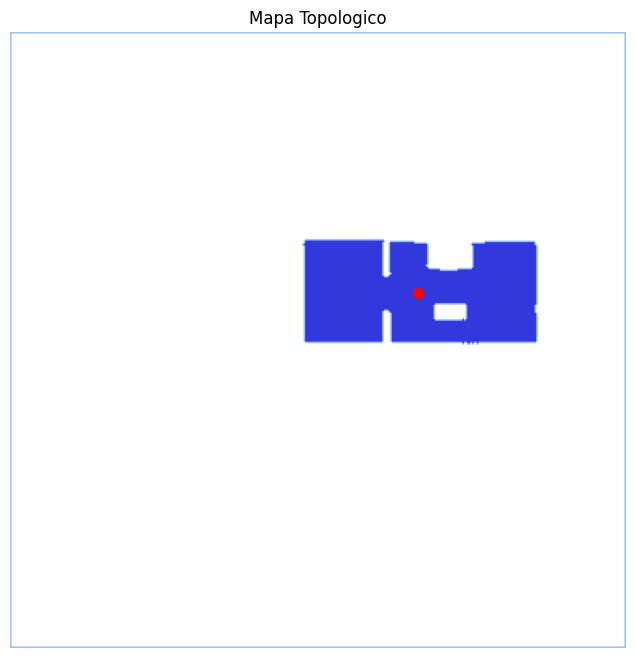

Pares adyacentes detectados (sin filtro): 0
Ejemplo de pares: []
Conexiones detectadas (con filtro): 0


In [22]:
# 1) Extraemos los perimetros de cada region segmentada
# La etiqueta 1 corresponde al fondo
perimetros = []
for etiqueta in range(2, etiquetas.max() + 1):
    region = (etiquetas == etiqueta).astype(np.uint8)
    contornos, _ = cv2.findContours(region, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contornos:
        contorno_principal = max(contornos, key=cv2.contourArea)
        perimetros.append(contorno_principal[:, 0, :])

# 2) Detectamos separaciones entre regiones.
# Metodo A: adyacencia directa.
adjacencias = {}
h, w = etiquetas.shape
for i in range(h - 1):
    for j in range(w - 1):
        actual = int(etiquetas[i, j])
        derecha = int(etiquetas[i, j + 1])
        abajo = int(etiquetas[i + 1, j])

        if actual > 1 and derecha > 1 and actual != derecha:
            par = tuple(sorted((actual, derecha)))
            adjacencias.setdefault(par, []).append((i, j))

        if actual > 1 and abajo > 1 and actual != abajo:
            par = tuple(sorted((actual, abajo)))
            adjacencias.setdefault(par, []).append((i, j))

# Metodo B (fallback principal): analizar pixeles frontera (-1 y 1)
# y obtener pares de regiones que tocan esa frontera.
frontera_idx = np.transpose(np.where(etiquetas <= 1))
for i, j in frontera_idx:
    i_min = max(0, i - 1)
    i_max = min(h, i + 2)
    j_min = max(0, j - 1)
    j_max = min(w, j + 2)

    vec = etiquetas[i_min:i_max, j_min:j_max].flatten()
    regs = sorted({int(x) for x in vec if x > 1})
    if len(regs) < 2:
        continue

    # Si hay mas de 2 regiones, generamos pares combinados
    for a in range(len(regs)):
        for b in range(a + 1, len(regs)):
            par = (regs[a], regs[b])
            adjacencias.setdefault(par, []).append((int(i), int(j)))

# Convertimos adyacencias a puntos centrales + conexiones
puntosCentrales = []
conexiones = []
vecinos = []
pxVecinos = []

for par, pixeles in adjacencias.items():
    # filtro de ruido adaptativo
    if len(pixeles) < 3:
        continue

    pix = np.array(pixeles)
    y = int(np.median(pix[:, 0]))
    x = int(np.median(pix[:, 1]))

    puntosCentrales.append((y, x))
    conexiones.append(par)

    for p in pixeles:
        pxVecinos.append((int(p[0]), int(p[1])))
        vecinos.append(par)

# Visualizamos el resultado
plt.figure(figsize=(8, 8))
plt.imshow(etiquetas_coloreadas, cmap='tab20')
mapa_centros = {i + 2: centroides[i] for i in range(len(centroides))}
for punto_sep, etiquetas_conectadas in zip(puntosCentrales, conexiones):
    etiqueta1, etiqueta2 = etiquetas_conectadas
    if etiqueta1 in mapa_centros and etiqueta2 in mapa_centros:
        centro1 = mapa_centros[etiqueta1]
        centro2 = mapa_centros[etiqueta2]
        plt.plot([punto_sep[1], centro1[0]], [punto_sep[0], centro1[1]], 'b-', linewidth=1)
        plt.plot([punto_sep[1], centro2[0]], [punto_sep[0], centro2[1]], 'b-', linewidth=1)
for punto in centroides:
    plt.scatter(punto[0], punto[1], c='red', s=50)
for punto in puntosCentrales:
    plt.scatter(punto[1], punto[0], c='blue', s=50)
plt.title("Mapa Topologico")
plt.axis("off")
plt.show()

pares_adyacentes = sorted(list(adjacencias.keys()))
print(f"Pares adyacentes detectados (sin filtro): {len(pares_adyacentes)}")
print(f"Ejemplo de pares: {pares_adyacentes[:10]}")
print(f"Conexiones detectadas (con filtro): {len(conexiones)}")

Quinto paso: Extracción de sub-nodos con Voronoi

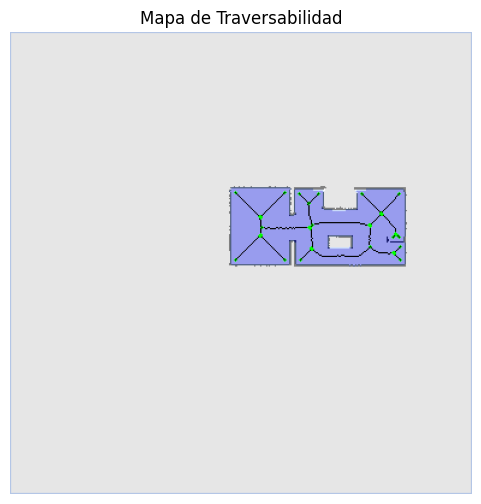

In [23]:
# 1) Extraemos puntos relevantes en funcion del esqueleto de la imagen
# Preprocesamos para separar los subnodos de las paredes
mapa_pre_esqueleto = cv2.erode(mapa_binario, np.ones((5, 5), np.uint8), iterations=1)
esqueleto = morphology.medial_axis(mapa_pre_esqueleto > 0).astype(np.uint8)

# Seleccionar px del esqueleto que tenga 1 vecino (esquina) o 3 vecinos (nodo interno)
coord_subnodos = []
px_as_tuples = np.transpose(np.where(esqueleto == 1))
for px in px_as_tuples:
    i, j = px
    i_min = max(0, i - 1)
    i_max = min(esqueleto.shape[0], i + 2)
    j_min = max(0, j - 1)
    j_max = min(esqueleto.shape[1], j + 2)

    neighbors = esqueleto[i_min:i_max, j_min:j_max]
    num_neighbors = int(np.sum(neighbors))

    # Array incluyendo el punto seleccionado junto a sus vecinos
    if num_neighbors == 2 or num_neighbors > 3:
        # Guardamos puntos con un vecino o mas de dos
        coord_subnodos.append(tuple(px))

# 2) Asignamos cada nodo del esqueleto a un perimetro
# Creamos un objeto Polygon para cada perimetro valido
poligonos = []
for idx, perimetro in enumerate(perimetros):
    if len(perimetro) >= 3:
        poligonos.append((idx + 2, Polygon(perimetro)))

regionSubNodos = []
for node in coord_subnodos:
    point = Point((node[1], node[0]))
    region = -1
    for etiqueta_region, poligono in poligonos:
        if poligono.is_valid and (poligono.contains(point) or poligono.touches(point)):
            region = etiqueta_region
            break
    regionSubNodos.append(region)

# Visualizamos el resultado
overlay = cv2.addWeighted(cv2.cvtColor(mapa, cv2.COLOR_GRAY2BGR), 0.5, etiquetas_coloreadas, 0.5, 0)
overlay[esqueleto == 1] = [0, 0, 0]
for nodo in coord_subnodos:
    overlay = cv2.circle(overlay, (nodo[1], nodo[0]), 1, (0, 255, 0), 1)
plt.figure(figsize=(6, 6))
plt.imshow(overlay)
plt.title("Mapa de Traversabilidad")
plt.axis("off")
plt.show()

Sexto paso: Guardar en fichero

In [24]:
# - Salida: - archivo mapaTopo.txt con la informacion de los nodos correspondientes a las zonas de conexion [X Y zona1 zona2]
#           - archivo subNodos.txt con la informacion de los sub-nodos dentro de cada zona [X Y zona]

# Carpeta configurable de salida (absoluta para evitar confusion de cwd)
base_dir = ruta_yaml.parent if 'ruta_yaml' in globals() else Path.cwd()
output_dir = (base_dir / "resultados_topomap").resolve()
output_dir.mkdir(parents=True, exist_ok=True)

ruta_mapa_topo = output_dir / "mapaTopo.txt"
ruta_subnodos = output_dir / "subNodos.txt"

# Guardamos coordenadas en formato [X Y ...] (X=columna, Y=fila)
with open(ruta_mapa_topo, 'w') as file:  # puntosCentrales, conexiones
    for i in range(len(puntosCentrales)):
        y, x = puntosCentrales[i]
        z1, z2 = conexiones[i]
        file.write(f"[{x} {y} {z1} {z2}]\n")

with open(ruta_subnodos, 'w') as file:
    for i in range(len(coord_subnodos)):
        y, x = coord_subnodos[i]
        file.write(f"[{x} {y} {regionSubNodos[i]}]\n")

# Guardado adicional de imagenes para la documentacion/entrega
ruta_segmentado = output_dir / "mapa_segmentado.png"
ruta_topologico = output_dir / "mapa_topologico.png"
ruta_traversabilidad = output_dir / "mapa_traversabilidad.png"

ok_segmentado = cv2.imwrite(str(ruta_segmentado), cv2.cvtColor(etiquetas_coloreadas, cv2.COLOR_RGB2BGR))

# Topologico (dibujo sobre el segmentado)
img_topo = etiquetas_coloreadas.copy()
mapa_centros = {i + 2: centroides[i] for i in range(len(centroides))}
for punto_sep, etiquetas_conectadas in zip(puntosCentrales, conexiones):
    etiqueta1, etiqueta2 = etiquetas_conectadas
    if etiqueta1 in mapa_centros and etiqueta2 in mapa_centros:
        centro1 = mapa_centros[etiqueta1]
        centro2 = mapa_centros[etiqueta2]
        cv2.line(img_topo, (punto_sep[1], punto_sep[0]), (centro1[0], centro1[1]), (255, 0, 0), 1)
        cv2.line(img_topo, (punto_sep[1], punto_sep[0]), (centro2[0], centro2[1]), (255, 0, 0), 1)
for punto in centroides:
    cv2.circle(img_topo, (punto[0], punto[1]), 3, (255, 0, 0), -1)
for punto in puntosCentrales:
    cv2.circle(img_topo, (punto[1], punto[0]), 3, (0, 0, 255), -1)
ok_topologico = cv2.imwrite(str(ruta_topologico), cv2.cvtColor(img_topo, cv2.COLOR_RGB2BGR))

ok_traversabilidad = cv2.imwrite(str(ruta_traversabilidad), cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

print(f"Output dir: {output_dir}")
print(f"Conexiones escritas en mapaTopo.txt: {len(conexiones)}")
print(f"Subnodos escritos en subNodos.txt: {len(coord_subnodos)}")
print(f"TXT guardado: {ruta_mapa_topo} (existe={ruta_mapa_topo.exists()})")
print(f"TXT guardado: {ruta_subnodos} (existe={ruta_subnodos.exists()})")
print(f"PNG guardado: {ruta_segmentado} (ok={ok_segmentado}, existe={ruta_segmentado.exists()})")
print(f"PNG guardado: {ruta_topologico} (ok={ok_topologico}, existe={ruta_topologico.exists()})")
print(f"PNG guardado: {ruta_traversabilidad} (ok={ok_traversabilidad}, existe={ruta_traversabilidad.exists()})")

Output dir: \\wsl.localhost\Ubuntu-20.04\home\ubuntu20\Ubuntu20noetic_ws\src\robots_moviles\navegacion_geometrica\mapas\exploration\resultados_topomap
Conexiones escritas en mapaTopo.txt: 0
Subnodos escritos en subNodos.txt: 41
TXT guardado: \\wsl.localhost\Ubuntu-20.04\home\ubuntu20\Ubuntu20noetic_ws\src\robots_moviles\navegacion_geometrica\mapas\exploration\resultados_topomap\mapaTopo.txt (existe=True)
TXT guardado: \\wsl.localhost\Ubuntu-20.04\home\ubuntu20\Ubuntu20noetic_ws\src\robots_moviles\navegacion_geometrica\mapas\exploration\resultados_topomap\subNodos.txt (existe=True)
PNG guardado: \\wsl.localhost\Ubuntu-20.04\home\ubuntu20\Ubuntu20noetic_ws\src\robots_moviles\navegacion_geometrica\mapas\exploration\resultados_topomap\mapa_segmentado.png (ok=True, existe=True)
PNG guardado: \\wsl.localhost\Ubuntu-20.04\home\ubuntu20\Ubuntu20noetic_ws\src\robots_moviles\navegacion_geometrica\mapas\exploration\resultados_topomap\mapa_topologico.png (ok=True, existe=True)
PNG guardado: \\wsl.